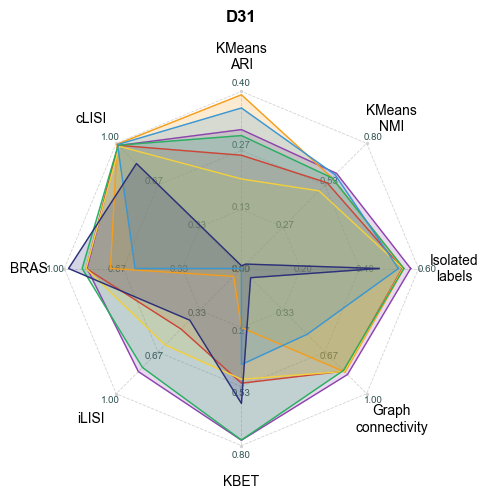

=== 各指标独立取值范围 ===
Isolated labels 0 - 0.6
KMeans NMI      0 - 0.8
KMeans ARI      0 - 0.4
cLISI           0 - 1.0
BRAS            0 - 1.0
iLISI           0 - 1.0
KBET            0 - 0.8
Graph connectivity 0 - 1.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D
import os

# =====================================================
# 1. 全局样式配置
# =====================================================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False

# 字号配置（微调：缩小指标名称字号，避免占用过多空间）
TINY_SIZE = 10 # 39
SMALL_SIZE = 10  # 42
MEDIUM_SIZE = 10  # 46
BIGGER_SIZE = 12  # 46

# 统一配色板
palette =  {
    'UniDISA': '#8E44AD',  # 紫 
    'MaxFuse': '#CD4537',    # 红
    'scConfluence': '#F59E1D',# 橙
    'BindSC': '#F4D03E',     # 黄
    'GLUE': '#28AF60',       # 绿
    'Seurat': '#3A97D2',     # 浅蓝
    'Uniport': '#2C3078'     # 深蓝
}


# ---------------------- 数据读取与处理 ----------------------
def load_and_validate_data(xlsx_path, sheet_name, methods, metrics):
    """读取指定Sheet数据（仅清洗NaN，保留原始值）"""
    try:
        df = pd.read_excel(xlsx_path, sheet_name=sheet_name, index_col=0)
        
        # 校验方法/指标
        missing_methods = [m for m in methods if m not in df.index]
        missing_metrics = [m for m in metrics if m not in df.columns]
        if missing_methods:
            raise ValueError(f"Sheet [{sheet_name}] 缺失方法：{', '.join(missing_methods)}")
        if missing_metrics:
            raise ValueError(f"Sheet [{sheet_name}] 缺失指标：{', '.join(missing_metrics)}")
        
        # 仅转换类型+填充NaN（原始均值）
        for metric in metrics:
            df[metric] = pd.to_numeric(df[metric], errors='coerce')
        df[metrics] = df[metrics].fillna(df[metrics].mean(axis=0))
        
        return df
    except FileNotFoundError:
        raise FileNotFoundError(f"XLSX文件路径错误：{xlsx_path}")
    except ImportError:
        raise ImportError("需安装openpyxl：pip install openpyxl")
    except Exception as e:
        raise Exception(f"Sheet [{sheet_name}] 处理失败：{str(e)}")

def get_metric_independent_range(xlsx_path, sheet_names, methods, metrics):
    """
    为每个指标计算独立取值范围（0到自身最大值向上取整到0.2倍数）
    返回：字典 {metric: (0, adaptive_max)}
    """
    all_data = []
    for sheet_name in sheet_names:
        df = load_and_validate_data(xlsx_path, sheet_name, methods, metrics)
        all_data.append(df[metrics])
    combined_df = pd.concat(all_data)
    
    metric_ranges = {}
    for metric in metrics:
        # 该指标的全局最大值
        metric_max = combined_df[metric].max()
        # 向上取整到0.2的整数倍（如0.08→0.2，0.15→0.2，0.95→1.0）
        adaptive_max = np.ceil(metric_max / 0.2) * 0.2
        # 限制最大不超过1.0（可根据需求取消）
        adaptive_max = min(adaptive_max, 1.0)
        metric_ranges[metric] = (0, adaptive_max)
    
    return metric_ranges


# ---------------------- 核心绘图函数（每个指标独立轴+环形轮廓线） ----------------------
def plot_independent_axis_radar(ax, df, metrics, metric_ranges, palette, title):
    """
    绘制单张雷达图（每个指标独立轴范围+环形轮廓线）
    :param ax: 绘图轴
    :param df: 当前Sheet的原始数据
    :param metrics: 指标列表（原始名称，和Excel一致）
    :param metric_ranges: 每个指标的范围字典
    :param palette: 配色字典
    :param title: 图表标题
    """
    # 1. 基础设置（保持原坐标轴范围，不扩大，符合画布不变要求）
    ax.set_aspect('equal')
    ax.set_xlim(-1.2, 1.2)  # 保持原范围，不放大
    ax.set_ylim(-1.2, 1.2)
    ax.axis('off')  # 隐藏默认坐标轴
    ax.set_title(title, fontsize=BIGGER_SIZE, fontweight='bold', pad=25)  # 微调标题间距，不压图表
    
    # 2. 计算每个指标的角度（均分360度）
    num_metrics = len(metrics)
    angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False)
    
    # 3. 绘制每个指标的独立轴（辅助线+刻度+标签）
    radial_levels = 4  # 每个指标的径向刻度数
    tick_coords_dict = {level: [] for level in range(radial_levels)}
    
    for i, metric in enumerate(metrics):
        angle = angles[i]
        min_val, max_val = metric_ranges[metric]
        tick_values = np.linspace(min_val, max_val, radial_levels)
        
        # 绘制径向辅助线+刻度点+刻度标签
        for level, tick in enumerate(tick_values):
            ratio = tick / max_val if max_val != 0 else 0
            x = ratio * np.cos(angle)
            y = ratio * np.sin(angle)
            tick_coords_dict[level].append((x, y))
            ax.scatter(x, y, color='lightgray', s=2, zorder=1)
            # 保持刻度标签位置不变，避免外扩遮挡
            ax.text(x * 1.05, y * 1.05, f"{tick:.2f}", 
                    fontsize=7, ha='center', va='center', 
                    color='darkslategray', zorder=2)
        
        # 绘制指标轴主线
        x_max = np.cos(angle)
        y_max = np.sin(angle)
        ax.plot([0, x_max], [0, y_max], color='lightgray', linewidth=0.6, linestyle='--', zorder=1)
        
        # ========== 关键修正：仅在显示时替换空格为换行，不修改原始指标名 ==========
        # 原始指标名（用于数据处理）：Isolated labels
        # 显示用指标名（用于图表标签）：Isolated\nlabels
        display_metric = metric.replace(' ', '\n')  # 仅在绘制标签时换行，不影响数据匹配
        ax.text(x_max * 1.2, y_max * 1.2, display_metric, 
                fontsize=TINY_SIZE, fontweight='medium', 
                ha='center', va='center', zorder=3)
    
    # 绘制环形轮廓线
    for level in tick_coords_dict:
        coords = tick_coords_dict[level]
        coords.append(coords[0])
        xs, ys = zip(*coords)
        ax.plot(xs, ys, color='lightgray', linewidth=0.6, linestyle='--', zorder=1)
    
    # 4. 绘制每个方法的雷达区域（保持zorder，让图表在文字下层不遮挡）
    methods = df.index.tolist()
    for method in methods:
        if method not in palette:
            continue
        color = palette[method]
        coords = []
        for i, metric in enumerate(metrics):
            angle = angles[i]
            min_val, max_val = metric_ranges[metric]
            value = df.loc[method, metric]
            ratio = value / max_val if max_val != 0 else 0
            ratio = np.clip(ratio, 0, 1)
            x = ratio * np.cos(angle)
            y = ratio * np.sin(angle)
            coords.append((x, y))
        coords.append(coords[0])
        xs, ys = zip(*coords)
        # 调整zorder，让雷达图在文字下层，避免图表遮挡文字
        ax.plot(xs, ys, color=color, linewidth=1.0, zorder=3, label=method)  # 雷达线zorder=3
        ax.fill(xs, ys, color=color, alpha=0.2, zorder=2)  # 填充区域zorder=2（低于文字和雷达线）


# ---------------------- 绘制单张雷达图 ----------------------
# 核心配置参数
xlsx_path = r'D:\Scunpair_Project\Benchmark_result(strong_5repeat)\D31\bio_bc.xlsx'
sheet_names = ['repeat_1']
methods = ['UniDISA', 'MaxFuse', 'scConfluence', 'BindSC', 'GLUE', 'Seurat', 'Uniport']

# ========== 关键修正：恢复metrics为Excel中的原始名称（带空格，无\n），保证数据匹配 ==========
metrics = [
    'Isolated labels', 
    'KMeans NMI', 
    'KMeans ARI', 
    'cLISI', 
    'BRAS', 
    'iLISI', 
    'KBET', 
    'Graph connectivity'
]

target_sheet = sheet_names[0]
# 此时指标名称和Excel一致，能正常通过校验并读取数据
metric_ranges = get_metric_independent_range(xlsx_path, sheet_names, methods, metrics)

# 保持画布大小不变（5x5）
fig, ax = plt.subplots(1, 1, figsize=(5, 5))  

df_single = load_and_validate_data(xlsx_path, target_sheet, methods, metrics)
title_single = f'D31'
plot_independent_axis_radar(ax, df_single, metrics, metric_ranges, palette, title_single)

# 微调子图间距，不扩大画布
plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.05)

# 保存图片
plt.savefig(
    f"Fig_2e雷达图.jpg",
    dpi=500,
    bbox_inches='tight',
    facecolor='white',
    edgecolor='none'
)

plt.show()

# 打印指标范围
print("=== 各指标独立取值范围 ===")
for metric, (min_val, max_val) in metric_ranges.items():
    print(f"{metric:<15} 0 - {max_val:.1f}")